In [1]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
def load_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(l) for l in f)

ft  = load_jsonl('eval_results.jsonl')
base = load_jsonl('eval_results_base_gemma.jsonl')

# Align on index i so comparisons are paired
ft   = ft.set_index('i').sort_index()
base = base.set_index('i').sort_index()

print(f'Fine-tuned rows: {len(ft)}   Base rows: {len(base)}')
print(f'Label classes: {sorted(ft.gt_label.unique())}')

Fine-tuned rows: 100   Base rows: 100
Label classes: ['under-qualified', 'well-matched']


## 1 — Summary metrics

In [3]:
def summary(df, name):
    valid = df[df.json_ok]
    return {
        'model':          name,
        'n':              len(df),
        'json_ok %':      df.json_ok.mean() * 100,
        'schema_ok %':    df.schema_complete.mean() * 100,
        'label_acc %':    df.label_correct.mean() * 100,
        'score_agree %':  df.score_agreed.mean() * 100,
        'MAE':            valid.score_error.abs().mean(),
        'RMSE':           np.sqrt((valid.score_error**2).mean()),
        'mean_bias':      valid.score_error.mean(),   # + = over-predict
    }

summary_df = pd.DataFrame([summary(ft, 'Fine-tuned'), summary(base, 'Base Gemma')])
summary_df = summary_df.set_index('model').T

# Colour cells so improvements pop
pd.set_option('display.float_format', '{:.2f}'.format)
display(summary_df)

model,Fine-tuned,Base Gemma
n,100.00,100.00
json_ok %,100.00,100.00
schema_ok %,100.00,100.00
label_acc %,87.00,64.00
score_agree %,75.00,49.00
MAE,9.11,13.49
RMSE,11.38,16.53
mean_bias,9.11,13.49


## 2 — Key metrics bar chart (success criteria)

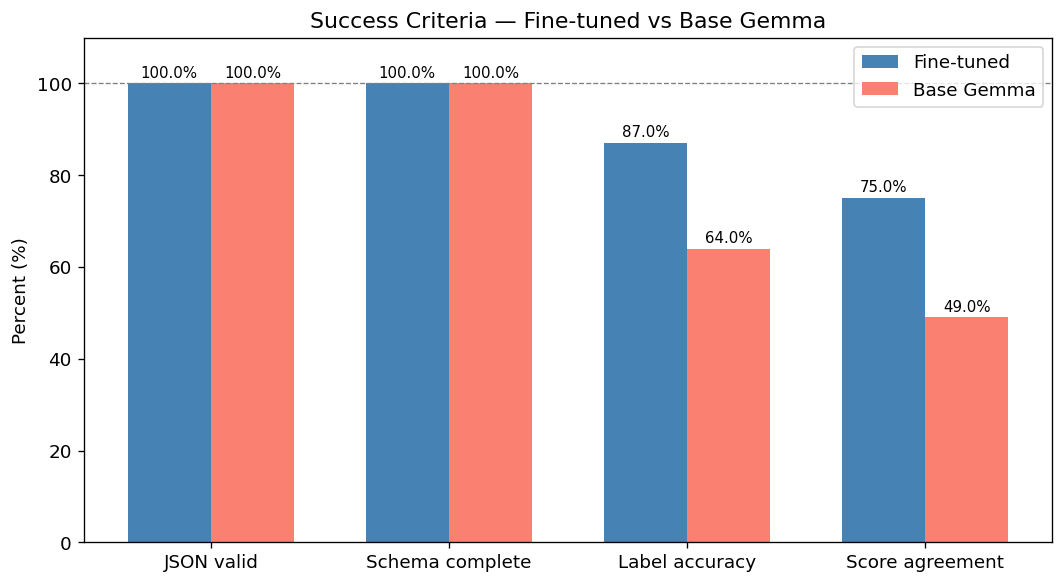

In [4]:
metrics = ['json_ok %', 'schema_ok %', 'label_acc %', 'score_agree %']
labels  = ['JSON valid', 'Schema complete', 'Label accuracy', 'Score agreement']

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - w/2, summary_df.loc[metrics, 'Fine-tuned'], w, label='Fine-tuned',  color='steelblue')
b2 = ax.bar(x + w/2, summary_df.loc[metrics, 'Base Gemma'],  w, label='Base Gemma',  color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percent (%)')
ax.set_ylim(0, 110)
ax.set_title('Success Criteria — Fine-tuned vs Base Gemma')
ax.legend()
ax.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=9)
ax.axhline(100, ls='--', lw=0.8, color='grey')
plt.tight_layout()
plt.savefig('success_criteria_comparison.png', bbox_inches='tight')
plt.show()

## 3 — Predicted score vs ground truth

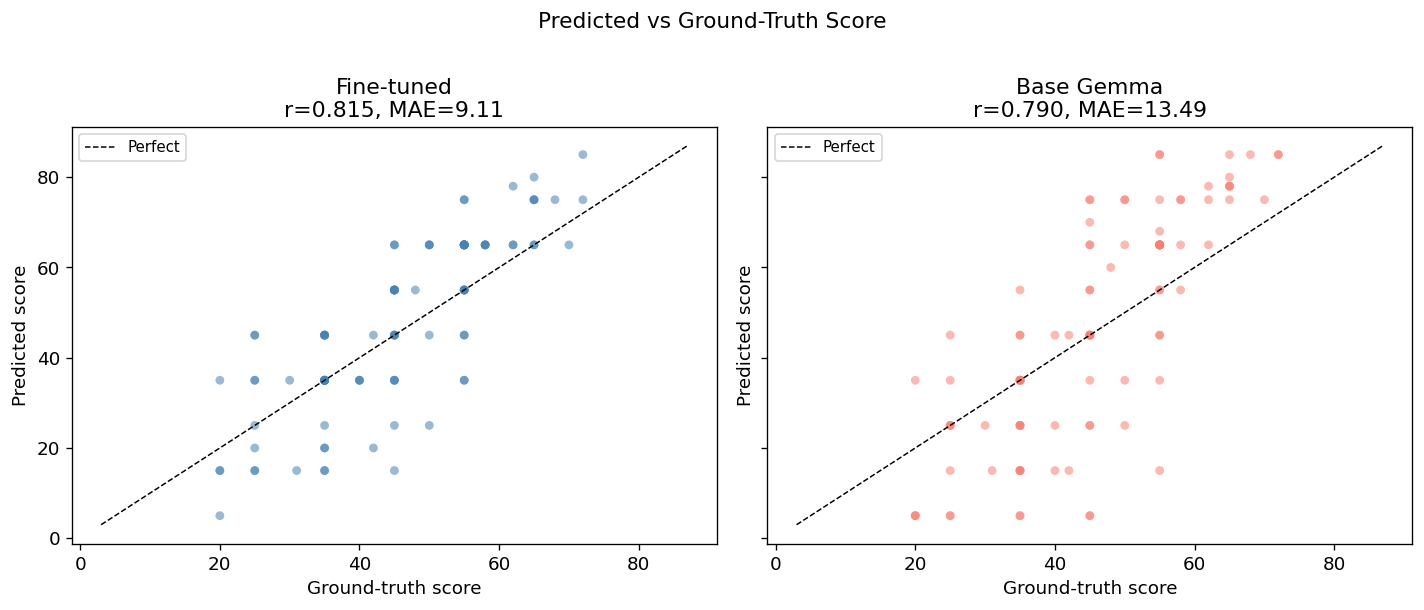

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, df, name, color in [
    (axes[0], ft,   'Fine-tuned', 'steelblue'),
    (axes[1], base, 'Base Gemma', 'salmon'),
]:
    valid = df[df.json_ok]
    ax.scatter(valid.gt_score, valid.pred_score, alpha=0.55, s=28, color=color, edgecolors='none')
    lo = min(valid.gt_score.min(), valid.pred_score.min()) - 2
    hi = max(valid.gt_score.max(), valid.pred_score.max()) + 2
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.9, label='Perfect')
    r, p = stats.pearsonr(valid.gt_score, valid.pred_score)
    mae  = valid.score_error.abs().mean()
    ax.set_title(f'{name}\nr={r:.3f}, MAE={mae:.2f}')
    ax.set_xlabel('Ground-truth score')
    ax.set_ylabel('Predicted score')
    ax.legend(fontsize=9)

fig.suptitle('Predicted vs Ground-Truth Score', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('score_scatter.png', bbox_inches='tight')
plt.show()

## 4 — Score error distributions

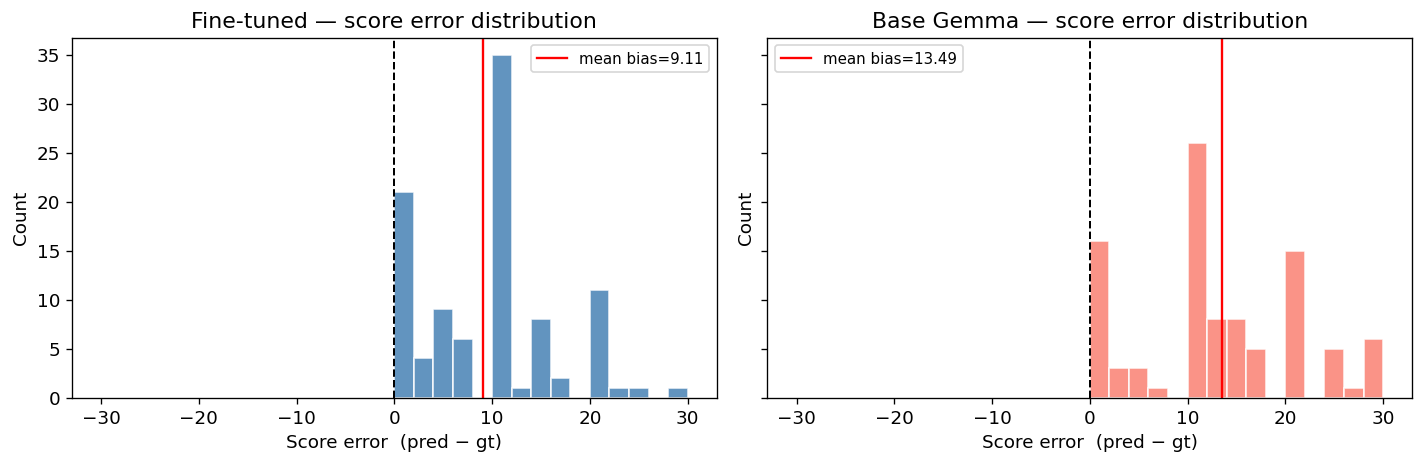

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = np.arange(-30, 31, 2)

for ax, df, name, color in [
    (axes[0], ft,   'Fine-tuned', 'steelblue'),
    (axes[1], base, 'Base Gemma', 'salmon'),
]:
    valid = df[df.json_ok]
    errs  = valid.score_error
    ax.hist(errs, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0,          color='black', lw=1.2, ls='--')
    ax.axvline(errs.mean(), color='red',  lw=1.4, label=f'mean bias={errs.mean():.2f}')
    ax.set_xlabel('Score error  (pred − gt)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — score error distribution')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('score_error_histogram.png', bbox_inches='tight')
plt.show()

## 5 — Systematic bias: error by ground-truth label

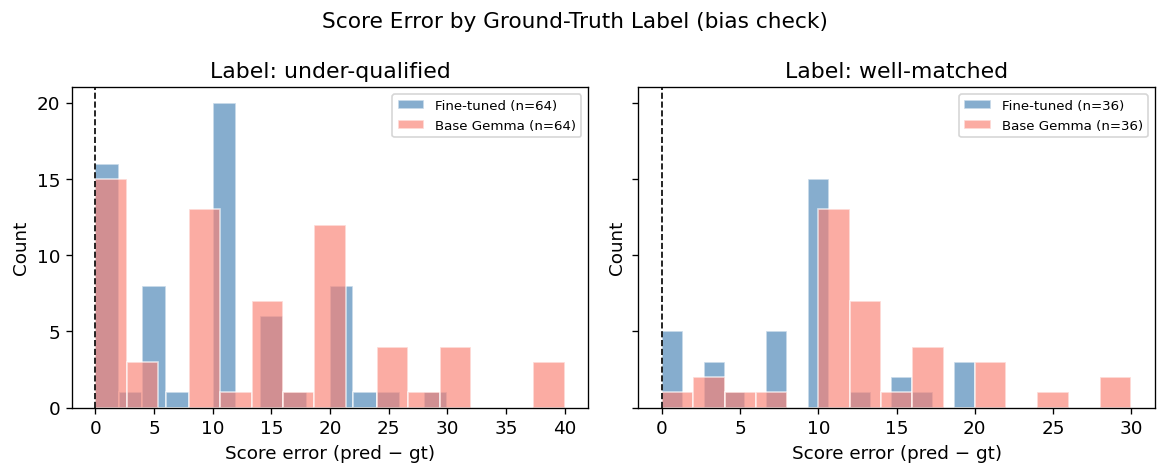

In [7]:
labels_list = sorted(ft.gt_label.unique())
fig, axes = plt.subplots(1, len(labels_list), figsize=(5 * len(labels_list), 4), sharey=True)

if len(labels_list) == 1:
    axes = [axes]

for ax, lbl in zip(axes, labels_list):
    ft_err   = ft[(ft.json_ok) & (ft.gt_label == lbl)].score_error
    base_err = base[(base.json_ok) & (base.gt_label == lbl)].score_error
    ax.hist(ft_err,   bins=15, alpha=0.65, label=f'Fine-tuned (n={len(ft_err)})',  color='steelblue', edgecolor='white')
    ax.hist(base_err, bins=15, alpha=0.65, label=f'Base Gemma (n={len(base_err)})', color='salmon',    edgecolor='white')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(f'Label: {lbl}')
    ax.set_xlabel('Score error (pred − gt)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Score Error by Ground-Truth Label (bias check)', fontsize=13)
plt.tight_layout()
plt.savefig('bias_by_label.png', bbox_inches='tight')
plt.show()

## 6 — Systematic bias: error by ground-truth score bucket

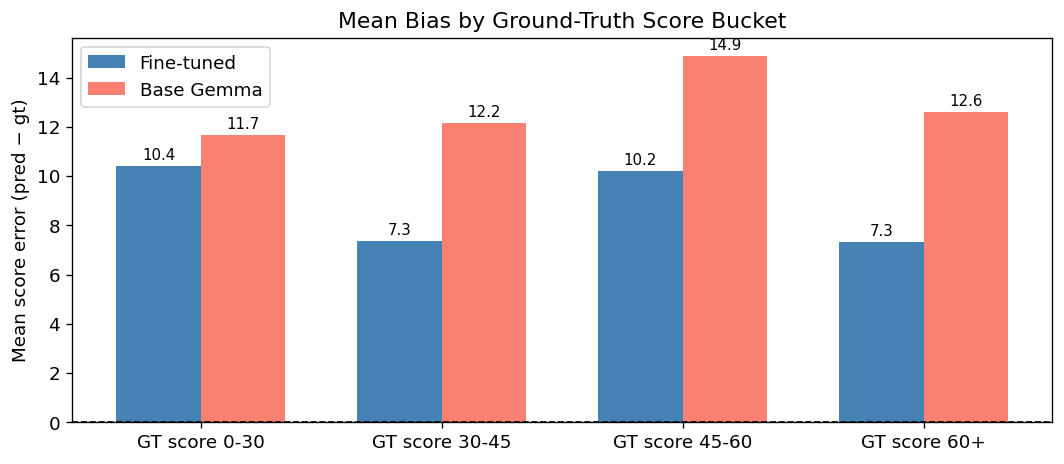

In [8]:
bins_score = [0, 30, 45, 60, 100]
bin_labels = ['0-30', '30-45', '45-60', '60+']

ft_v   = ft[ft.json_ok].copy()
base_v = base[base.json_ok].copy()
ft_v['bucket']   = pd.cut(ft_v.gt_score,   bins=bins_score, labels=bin_labels, right=False)
base_v['bucket'] = pd.cut(base_v.gt_score, bins=bins_score, labels=bin_labels, right=False)

ft_bias   = ft_v.groupby('bucket', observed=True).score_error.mean()
base_bias = base_v.groupby('bucket', observed=True).score_error.mean()

x = np.arange(len(bin_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, ft_bias.reindex(bin_labels),   w, label='Fine-tuned', color='steelblue')
b2 = ax.bar(x + w/2, base_bias.reindex(bin_labels), w, label='Base Gemma', color='salmon')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xticks(x)
ax.set_xticklabels([f'GT score {b}' for b in bin_labels])
ax.set_ylabel('Mean score error (pred − gt)')
ax.set_title('Mean Bias by Ground-Truth Score Bucket')
ax.legend()
ax.bar_label(b1, fmt='%.1f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.1f', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig('bias_by_score_bucket.png', bbox_inches='tight')
plt.show()

## 7 — Label confusion: where do misclassifications land?

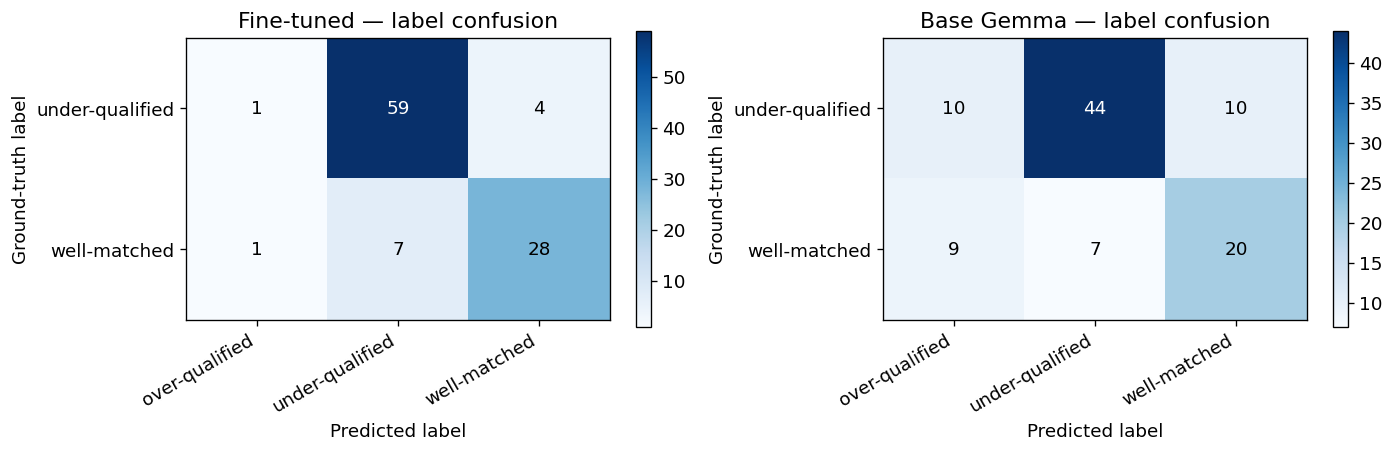

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, name in [(axes[0], ft, 'Fine-tuned'), (axes[1], base, 'Base Gemma')]:
    ct = pd.crosstab(df.gt_label, df.pred_label, margins=False)
    im = ax.imshow(ct.values, cmap='Blues')
    ax.set_xticks(range(len(ct.columns)))
    ax.set_yticks(range(len(ct.index)))
    ax.set_xticklabels(ct.columns, rotation=30, ha='right')
    ax.set_yticklabels(ct.index)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Ground-truth label')
    ax.set_title(f'{name} — label confusion')
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, str(ct.values[i, j]), ha='center', va='center',
                    color='white' if ct.values[i, j] > ct.values.max() / 2 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('label_confusion.png', bbox_inches='tight')
plt.show()

## 8 — Paired delta: per-sample improvement from fine-tuning

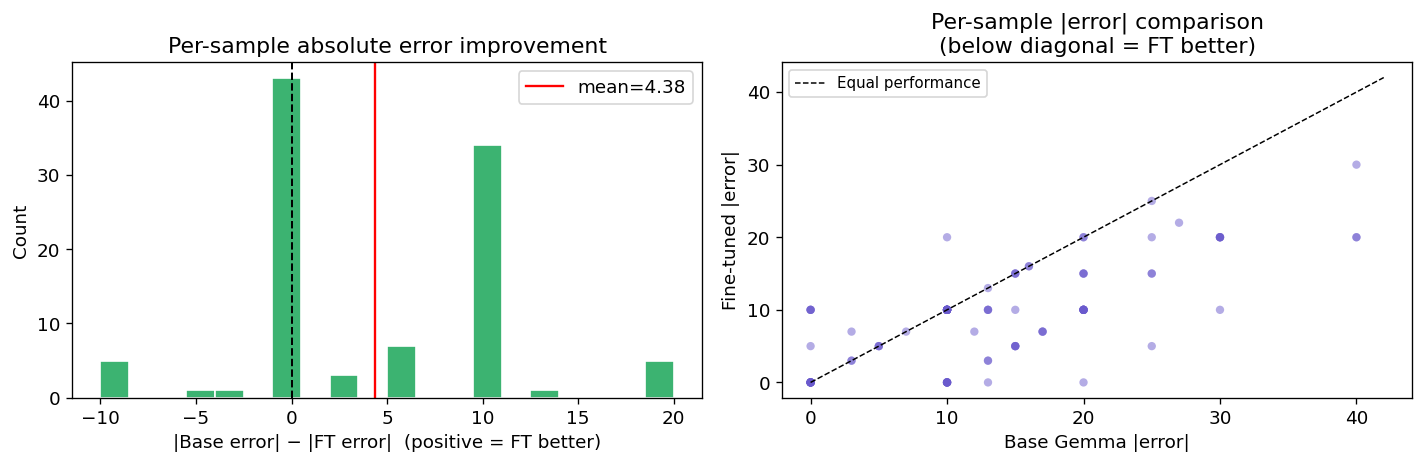

Fine-tuned improved on 50.0% of samples, worse on 7.0%, tied on 43.0%


In [10]:
# Only samples where both models parsed JSON
shared = ft.index.intersection(base.index)
both_ok = shared[(ft.loc[shared, 'json_ok']) & (base.loc[shared, 'json_ok'])]

delta_abs_err = base.loc[both_ok, 'score_error'].abs() - ft.loc[both_ok, 'score_error'].abs()
# positive delta => fine-tune improved that sample

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delta_abs_err, bins=20, color='mediumseagreen', edgecolor='white')
axes[0].axvline(0, color='black', lw=1.2, ls='--')
axes[0].axvline(delta_abs_err.mean(), color='red', lw=1.4,
                label=f'mean={delta_abs_err.mean():.2f}')
axes[0].set_xlabel('|Base error| − |FT error|  (positive = FT better)')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-sample absolute error improvement')
axes[0].legend()

# Scatter: base abs error vs ft abs error per sample
axes[1].scatter(base.loc[both_ok, 'score_error'].abs(),
                ft.loc[both_ok, 'score_error'].abs(),
                alpha=0.5, s=25, color='slateblue', edgecolors='none')
lim = max(base.loc[both_ok, 'score_error'].abs().max(),
          ft.loc[both_ok, 'score_error'].abs().max()) + 2
axes[1].plot([0, lim], [0, lim], 'k--', lw=0.9, label='Equal performance')
axes[1].set_xlabel('Base Gemma |error|')
axes[1].set_ylabel('Fine-tuned |error|')
axes[1].set_title('Per-sample |error| comparison\n(below diagonal = FT better)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('per_sample_improvement.png', bbox_inches='tight')
plt.show()

pct_improved = (delta_abs_err > 0).mean() * 100
pct_worse    = (delta_abs_err < 0).mean() * 100
print(f'Fine-tuned improved on {pct_improved:.1f}% of samples, '
      f'worse on {pct_worse:.1f}%, tied on {100-pct_improved-pct_worse:.1f}%')